In [44]:
"""
NCKH - Promotion Recommendation Model
Kiến trúc: GRU (sequence encoder) -> Decision Tree (final classifier)
Dataset: eCommerce Events History in Cosmetics Shop (Kaggle)
"""

import os
import glob
import gc
import pandas as pd
import numpy as np


# Dynamic Path Setup for IDE and Kernel safety
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
FIG_DIR = os.path.join(BASE_DIR, "figures", "gru")
OUT_DIR = os.path.join(BASE_DIR, "outputs", "gru")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Data-driven sequence and outcome configuration from Behavioral_EDA.ipynb.
SESSION_GAP_MIN = 30
MAX_LEN = 8
PURCHASE_WINDOW_HOURS = 24
PURCHASE_WINDOW_MINUTES = PURCHASE_WINDOW_HOURS * 60
print(f"GRU config: MAX_LEN={MAX_LEN}, purchase window={PURCHASE_WINDOW_HOURS}h")


GRU config: MAX_LEN=8, purchase window=24h


In [45]:
import kagglehub

path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop"
)
print("Dataset path:", path)


Dataset path: /Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6


### 1. Đọc và làm sạch dữ liệu

Notebook tải bộ dữ liệu hành vi e-commerce mỹ phẩm từ Kaggle, sau đó xử lý theo các bước:

1. Đọc các file CSV theo từng chunk để hạn chế sử dụng RAM.
2. Giữ mẫu người dùng theo `SAMPLE_USER_MOD` và loại các bản ghi có giá không hợp lệ.
3. Loại bản ghi trùng theo người dùng, sản phẩm, loại sự kiện và thời điểm.
4. Chuẩn hóa tên sự kiện về schema của pipeline GRU.
5. Chuyển thời gian sang kiểu datetime, chuẩn hóa khóa người dùng/sản phẩm và tạo các biến giá, biên lợi nhuận, traffic, macro và thời gian chờ.

Dữ liệu sau bước này là đầu vào thống nhất cho bước chia session, tạo nhãn `purchase_within_24h` và xây dựng chuỗi hành vi.


In [46]:
# ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# Dataset Kaggle lớn (~20 triệu dòng). Lấy mẫu user để notebook chạy được;
# đặt SAMPLE_USER_MOD = None nếu muốn đọc toàn bộ (cần RAM lớn).
SAMPLE_USER_MOD = 100          # 100 -> ~1% user (user_id % 100 == 0)
CHUNK = 2_000_000
MARGIN_RATE = 0.30             # dataset không có cost -> giả định biên gộp

files = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
files = [f for f in files if os.path.getsize(f) > 1_000_000]
print("Số file CSV:", len(files))
for f in files:
    print(" ", os.path.basename(f))

COLS = [
    "event_time", "event_type", "product_id", "category_id",
    "brand", "price", "user_id",
]
DT = {
    "event_type": "category",
    "product_id": "int64",
    "category_id": "int64",
    "price": "float32",
    "user_id": "int64",
    "brand": "string",
}

parts, n_raw, n_bad, n_dup = [], 0, 0, 0
for f in files:
    print("  đọc", os.path.basename(f))
    for ch in pd.read_csv(f, usecols=COLS, dtype=DT, chunksize=CHUNK):
        n_raw += len(ch)
        if SAMPLE_USER_MOD is not None:
            ch = ch.loc[ch["user_id"] % SAMPLE_USER_MOD == 0]
        bad = ~(ch["price"] > 0)
        n_bad += int(bad.sum())
        ch = ch.loc[~bad].copy()
        b0 = len(ch)
        ch = ch.drop_duplicates(
            subset=["user_id", "product_id", "event_type", "event_time"]
        )
        n_dup += b0 - len(ch)
        parts.append(ch)
        del ch
    gc.collect()

df = pd.concat(parts, ignore_index=True)
del parts
gc.collect()

print(f"Dòng thô {n_raw:,} | loại price<=0 {n_bad:,} | khử trùng {n_dup:,}")
print("Sau lọc mẫu:", df.shape)

# --- Map tên cột / loại sự kiện về schema notebook GRU gốc ---
EVENT_RENAME = {
    "view": "detail_click",
    "cart": "add_to_cart",
    "remove_from_cart": "remove_cart",
    "purchase": "purchase",
}
df["event_type_behav"] = df["event_type"].astype(str).map(EVENT_RENAME)
df = df.dropna(subset=["event_type_behav"]).copy()

df["timestamp"] = pd.to_datetime(
    df["event_time"].astype(str).str.slice(0, 19),
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce",
)
df = df.dropna(subset=["timestamp", "user_id"]).copy()
df["user_id"] = df["user_id"].astype(str)
df["product_id"] = df["product_id"].astype(str)

# Giá / biên / cost (dataset chỉ có price)
df["base_price"] = pd.to_numeric(df["price"], errors="coerce")
df["market_price"] = df.groupby("product_id")["base_price"].transform("median")
df["cost"] = df["base_price"] * (1.0 - MARGIN_RATE)
df["margin"] = MARGIN_RATE
df["quantity"] = 1.0
df["revenue"] = np.where(df["event_type_behav"].eq("purchase"), df["base_price"], 0.0)
df["stock"] = 0.0

# Mức giảm giá suy ra so với giá median của sản phẩm
df["event_discount_level"] = (
    (df["market_price"] - df["base_price"]) / df["market_price"].replace(0, np.nan)
).clip(lower=0, upper=1).fillna(0.0)

# Brand -> category (giữ số nhóm nhỏ để one-hot giống notebook gốc)
top_brands = df["brand"].fillna("unknown").value_counts().head(8).index
df["category"] = (
    df["brand"].fillna("unknown")
    .where(df["brand"].fillna("unknown").isin(top_brands), "Other")
)

# traffic_level theo lưu lượng theo giờ
df["hour"] = df["timestamp"].dt.hour
hourly_volume = df.groupby("hour").size()
df["traffic_code_raw"] = df["hour"].map(hourly_volume)
df["traffic_level"] = pd.qcut(
    df["traffic_code_raw"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
).astype(str)

# macro_level / salary_period: proxy từ thời gian (dataset không có macro/lương)
df["macro_level"] = df["hour"].astype(float)
df["salary_period"] = df["timestamp"].dt.day.astype(float)

hour_bin = pd.cut(
    df["hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False,
    include_lowest=True,
)
df["event_type_macro"] = hour_bin.astype(str)

# dwell_time: số giây đến sự kiện kế tiếp của cùng user (0 nếu là sự kiện cuối)
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
next_ts = df.groupby("user_id")["timestamp"].shift(-1)
df["dwell_time"] = (next_ts - df["timestamp"]).dt.total_seconds().clip(lower=0).fillna(0)

print("Kích thước dữ liệu:", df.shape)
print("Phân bố event_type_behav:")
print(df["event_type_behav"].value_counts().to_string())
print(df[["timestamp", "user_id", "product_id", "event_type_behav",
          "base_price", "event_discount_level", "category"]].head())


Số file CSV: 5
  2019-Dec.csv
  2019-Nov.csv
  2019-Oct.csv
  2020-Feb.csv
  2020-Jan.csv
  đọc 2019-Dec.csv
  đọc 2019-Nov.csv
  đọc 2019-Oct.csv
  đọc 2020-Feb.csv
  đọc 2020-Jan.csv
Dòng thô 20,692,840 | loại price<=0 767 | khử trùng 11,865
Sau lọc mẫu: (203502, 7)
Kích thước dữ liệu: (203502, 25)
Phân bố event_type_behav:
event_type_behav
detail_click    99987
add_to_cart     57797
remove_cart     31531
purchase        14187
            timestamp    user_id product_id event_type_behav  base_price  \
0 2019-11-28 10:12:24  107768800    5862022     detail_click        5.56   
1 2019-12-13 15:44:56  107768800    5861731     detail_click       11.67   
2 2019-12-13 15:45:24  107768800    5912728     detail_click       29.32   
3 2019-12-17 09:27:00  109542400    5861721     detail_click        4.76   
4 2019-12-17 09:27:56  109542400    5861721     detail_click        4.76   

   event_discount_level category  
0                   0.0  unknown  
1                   0.0  unknown  
2    

### 2. Chia Session (Phiên)

Để hiểu hành vi của người dùng, chúng ta cần phân chia chuỗi các hành động thành các "phiên" riêng biệt. Một phiên được định nghĩa là một chuỗi hành động liên tục của người dùng, nếu có một khoảng thời gian dài (trên 30 phút) không có hành động nào, một phiên mới sẽ được bắt đầu.


In [47]:
# CHIA SESSION
# Quy tắc: nếu người dùng không có hành động mới trong hơn 30 phút, hệ thống coi đó là một session (phiên) mới.

df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

# Thời điểm hành vi trước đó của cùng một user
df["previous_timestamp"] = df.groupby("user_id")["timestamp"].shift(1)

# Khoảng cách thời gian giữa hai hành vi liên tiếp (tính bằng phút)
df["gap_minutes"] = (
    df["timestamp"] - df["previous_timestamp"]
).dt.total_seconds() / 60

# Đánh dấu bắt đầu session mới: hành vi đầu tiên của user, hoặc khoảng cách > 30 phút
df["new_session"] = (
    df["previous_timestamp"].isna() | (df["gap_minutes"] > 30)
).astype(int)

# Đánh số thứ tự session cho từng user
df["session_number"] = df.groupby("user_id")["new_session"].cumsum()
df["session_id"] = df["user_id"] + "_S" + df["session_number"].astype(str)

print("Số lượng session:", df["session_id"].nunique())


Số lượng session: 33955


### 3. Tạo nhãn `purchase_within_24h`

Đây là biến mục tiêu của mô hình: một hành vi `add_to_cart` được gán nhãn 1 nếu có giao dịch mua trong vòng 24 giờ tiếp theo. Giá trị này dùng `PURCHASE_WINDOW_HOURS` từ cell cấu hình đầu tiên.


In [48]:
# TẠO NHÃN (LABEL): purchase_within_24h
# Nhãn = 1 nếu sau hành vi hiện tại, khách hàng chốt đơn trong vòng PURCHASE_WINDOW_HOURS.
df = df.sort_values(
    ["session_id", "user_id", "product_id", "timestamp"]
).reset_index(drop=True)

# Chỉ giữ lại timestamp tại đúng dòng purchase, các dòng khác để trống
df["purchase_time_temp"] = df["timestamp"].where(
    df["event_type_behav"].eq("purchase")
)

# Lan truyền ngược thời điểm purchase trong tương lai về các dòng trước đó
df["next_purchase_timestamp"] = (
    df.groupby(["session_id", "user_id", "product_id"])["purchase_time_temp"]
    .bfill()
)

# Số phút từ thời điểm event hiện tại đến khi purchase xảy ra
df["minutes_to_purchase"] = (
    df["next_purchase_timestamp"] - df["timestamp"]
).dt.total_seconds() / 60

# Gán nhãn theo cửa sổ đã xác định từ Behavioral_EDA.ipynb
df["purchase_within_24h"] = (
    (df["minutes_to_purchase"] > 0)
    & (df["minutes_to_purchase"] <= PURCHASE_WINDOW_MINUTES)
).astype(int)


### 4. Mã hóa các đặc trưng cho GRU

Mô hình GRU (Gated Recurrent Unit) làm việc tốt với dữ liệu số. Do đó, chúng ta cần chuyển đổi các đặc trưng dạng văn bản hoặc danh mục thành dạng số.


In [49]:
# MÃ HÓA EVENT_TYPE_BEHAV CHO GRU (0 = padding)
EVENT_VOCAB = {
    "search_click": 1,
    "detail_click": 2,
    "wishlist": 3,
    "add_to_cart": 4,
    "remove_cart": 5,
    "purchase": 6,
}
df["event_code"] = df["event_type_behav"].map(EVENT_VOCAB).fillna(0).astype(int)

# Mã hóa traffic_level theo thứ tự tăng dần (ordinal encoding)
TRAFFIC_MAP = {"Low": 0, "Medium": 1, "High": 2, "Very High": 3}
df["traffic_code"] = df["traffic_level"].map(TRAFFIC_MAP).fillna(0).astype(int)

df["minutes_since_previous_event"] = df["gap_minutes"].fillna(0).clip(lower=0)
df["hour"] = df["timestamp"].dt.hour


### 5. Xây dựng chuỗi (sequence) cho từng điểm ra quyết định `add_to_cart`

Vì mô hình GRU được thiết kế để xử lý dữ liệu chuỗi, chúng ta cần chuyển đổi dữ liệu hành vi của người dùng thành các chuỗi sự kiện. Mỗi chuỗi đại diện cho bối cảnh hành vi của người dùng trước một hành động `add_to_cart`.


In [50]:
# XÂY DỰNG SEQUENCE CHO TỪNG QUYẾT ĐỊNH add_to_cart
# Mỗi case = chuỗi các event trong session TÍNH ĐẾN THỜI ĐIỂM add_to_cart
df_sorted = df.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

# Các đặc trưng số theo từng bước thời gian, sẽ đưa vào GRU
STEP_NUMERIC_COLS = [
    "dwell_time",
    "minutes_since_previous_event",
    "event_discount_level",
    "traffic_code",
    "macro_level",
    "hour",
]

decision_points = df_sorted[df_sorted["event_type_behav"].eq("add_to_cart")].copy()
decision_points = decision_points.reset_index(drop=True)

# Dataset Kaggle có rất nhiều add_to_cart; lấy mẫu để GRU/DT chạy được
MAX_CASES = 4000
if len(decision_points) > MAX_CASES:
    sampled = []
    n_each = MAX_CASES // 2
    for _, grp in decision_points.groupby("purchase_within_24h"):
        sampled.append(grp.sample(n=min(len(grp), n_each), random_state=42))
    decision_points = pd.concat(sampled, ignore_index=True)

decision_points = decision_points.reset_index(drop=True)
print("Số điểm ra quyết định (add_to_cart):", len(decision_points))

sequences_event = []     # chuỗi mã sự kiện của từng case
sequences_numeric = []   # chuỗi đặc trưng số theo từng bước
static_rows = []          # đặc trưng tĩnh của từng case
labels = []               # nhãn purchase_within_24h của từng case

# Gom nhóm trước theo session_id để tra cứu cực nhanh và khớp 1-1 với decision_points
sess_keep = set(decision_points["session_id"])
df_sess_dict = {
    sess: g.sort_values("timestamp")
    for sess, g in df_sorted[df_sorted["session_id"].isin(sess_keep)].groupby("session_id", sort=False)
}

for _, row in decision_points.iterrows():
    sess = row["session_id"]
    ts = row["timestamp"]
    g = df_sess_dict[sess]
    sess_events = g[g["timestamp"] <= ts].tail(MAX_LEN)

    sequences_event.append(sess_events["event_code"].to_numpy())
    sequences_numeric.append(sess_events[STEP_NUMERIC_COLS].to_numpy(dtype=float))

    # Đặc trưng tĩnh: bối cảnh tại thời điểm ra quyết định
    static_rows.append({
        "base_price": row["base_price"],
        "cost": row["cost"],
        "margin": row["margin"],
        "category": row["category"],
        "macro_level": row["macro_level"],
        "traffic_code": row["traffic_code"],
        "salary_period": row["salary_period"],
        "event_discount_level": row["event_discount_level"],
        "timestamp": row["timestamp"],
    })
    labels.append(row["purchase_within_24h"])

static_df = pd.DataFrame(static_rows)
labels = np.array(labels)

print("Số case:", len(labels), " | Tỷ lệ purchase_within_24h:", labels.mean())


Số điểm ra quyết định (add_to_cart): 4000
Số case: 4000  | Tỷ lệ purchase_within_24h: 0.5


### 6. Padding chuỗi và Chuẩn hóa đặc trưng số

Các chuỗi sự kiện có độ dài khác nhau, nhưng mô hình GRU yêu cầu tất cả các chuỗi đầu vào phải có cùng độ dài. Bước này sẽ 'đệm' (pad) các chuỗi ngắn hơn và cắt bớt các chuỗi dài hơn để chúng đều có độ dài `MAX_LEN`. Đồng thời, các đặc trưng số cũng được chuẩn hóa để cải thiện hiệu suất của mô hình.


In [51]:
# PADDING SEQUENCE (chuẩn hóa các chuỗi về cùng độ dài MAX_LEN)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Đệm (pad) chuỗi mã sự kiện về cùng độ dài, đệm ở đầu (padding="pre")
X_event = pad_sequences(
    sequences_event, maxlen=MAX_LEN, padding="pre", truncating="pre", value=0
)

# Đệm chuỗi đặc trưng số theo từng chiều (không dùng pad_sequences vì đây là mảng nhiều chiều)
n_numeric_feats = len(STEP_NUMERIC_COLS)
X_numeric = np.zeros((len(sequences_numeric), MAX_LEN, n_numeric_feats))
for i, seq in enumerate(sequences_numeric):
    L = min(len(seq), MAX_LEN)
    X_numeric[i, -L:, :] = seq[-L:]

# Chuẩn hóa (standardize) đặc trưng số theo từng chiều
# (ở đây fit trên toàn bộ dữ liệu cho đơn giản khi demo;
#  bản chính thức nên fit riêng trên tập train rồi transform sang tập test)
numeric_mean = X_numeric.reshape(-1, n_numeric_feats).mean(axis=0)
numeric_std = X_numeric.reshape(-1, n_numeric_feats).std(axis=0) + 1e-6
X_numeric_scaled = (X_numeric - numeric_mean) / numeric_std

print("Kích thước X_event:", X_event.shape)
print("Kích thước X_numeric:", X_numeric_scaled.shape)


Kích thước X_event: (4000, 8)
Kích thước X_numeric: (4000, 8, 6)


### 7. Đặc trưng tĩnh (Static Features)

Ngoài các đặc trưng chuỗi thay đổi theo thời gian, chúng ta còn có các đặc trưng tĩnh mô tả bối cảnh chung tại thời điểm đưa ra quyết định (ví dụ: giá cơ bản, danh mục sản phẩm). Các đặc trưng này sẽ được mã hóa và chuẩn hóa tương tự như các đặc trưng số khác.


In [52]:
# STATIC FEATURES (context tại thời điểm quyết định)
from sklearn.preprocessing import OneHotEncoder

static_numeric_cols = [
    "base_price", "cost", "margin", "macro_level",
    "traffic_code", "salary_period", "event_discount_level"
]

# Mã hóa one-hot cho ngành hàng (category)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
category_encoded = ohe.fit_transform(static_df[["category"]])

X_static = np.hstack([
    static_df[static_numeric_cols].to_numpy(dtype=float),
    category_encoded
])

static_mean = X_static.mean(axis=0)
static_std = X_static.std(axis=0) + 1e-6
X_static_scaled = (X_static - static_mean) / static_std

print("Kích thước X_static:", X_static_scaled.shape)


Kích thước X_static: (4000, 16)


### 8. Chia tập huấn luyện/kiểm thử theo thời gian

Để đảm bảo mô hình có thể dự đoán tốt trong tương lai và tránh rò rỉ dữ liệu, chúng ta chia dữ liệu thành tập huấn luyện (train) và tập kiểm thử (test) dựa trên yếu tố thời gian. Dữ liệu cũ hơn được dùng để huấn luyện, dữ liệu mới hơn để kiểm thử.


In [53]:
# TRAIN/TEST SPLIT THEO THỜI GIAN (80/20)
# Chia theo thời gian để tránh rò rỉ thông tin tương lai vào tập huấn luyện.
order = static_df["timestamp"].to_numpy().argsort()
n = len(order)
split_point = int(n * 0.8)

train_idx = order[:split_point]
test_idx = order[split_point:]

def split(arr):
    return arr[train_idx], arr[test_idx]

X_event_train, X_event_test = split(X_event)
X_numeric_train, X_numeric_test = split(X_numeric_scaled)
X_static_train, X_static_test = split(X_static_scaled)
y_train, y_test = split(labels)

print("Số case train:", len(y_train), " | Số case test:", len(y_test))
print("Tỷ lệ purchase (train):", y_train.mean(), " | (test):", y_test.mean())


Số case train: 3200  | Số case test: 800
Tỷ lệ purchase (train): 0.513125  | (test): 0.4475


### 9. Xây dựng mô hình GRU (Sequence Encoder)

Đây là phần cốt lõi của kiến trúc mô hình. Chúng ta sẽ xây dựng một mạng nơ-ron GRU để mã hóa các chuỗi hành vi của người dùng thành một vector đặc trưng duy nhất (embedding). Vector này sau đó sẽ được kết hợp với các đặc trưng tĩnh để đưa ra dự đoán.


In [54]:
# XÂY MÔ HÌNH GRU (sequence encoder + đầu ra phụ trợ)
import tensorflow as tf
from tensorflow.keras import layers, Model

VOCAB_SIZE = len(EVENT_VOCAB) + 1  # +1 dành cho giá trị padding (index 0)
EMBED_DIM = 8    # số chiều embedding cho mỗi loại sự kiện
GRU_UNITS = 16   # số đơn vị ẩn (hidden units) của tầng GRU

# 3 nhánh input: chuỗi sự kiện, chuỗi đặc trưng số theo bước, đặc trưng tĩnh
event_input = layers.Input(shape=(MAX_LEN,), name="event_seq")
numeric_input = layers.Input(shape=(MAX_LEN, n_numeric_feats), name="numeric_seq")
static_input = layers.Input(shape=(X_static_scaled.shape[1],), name="static_feats")

# Lớp embedding: chuyển mã sự kiện (số nguyên) thành vector đặc trưng
# mask_zero=True để GRU bỏ qua các bước bị padding (giá trị 0)
event_embed = layers.Embedding(
    input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True
)(event_input)

# Ghép embedding sự kiện với đặc trưng số theo từng bước thời gian
sequence_features = layers.Concatenate(axis=-1)([event_embed, numeric_input])

# Tầng GRU: đọc toàn bộ chuỗi, trả về 1 vector embedding tổng hợp hành vi
gru_out = layers.GRU(GRU_UNITS, name="gru_embedding")(sequence_features)

# Ghép embedding của GRU với đặc trưng tĩnh, qua vài tầng Dense để huấn luyện end-to-end
combined = layers.Concatenate()([gru_out, static_input])
dense_1 = layers.Dense(16, activation="relu")(combined)
output = layers.Dense(1, activation="sigmoid")(dense_1)

gru_model = Model(
    inputs=[event_input, numeric_input, static_input],
    outputs=output,
    name="GRU_purchase_predictor"
)

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

gru_model.summary()


Model: "GRU_purchase_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ event_seq           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 8, 8)      │         56 │ event_seq[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 8)         │          0 │ event_seq[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_seq         │ (None, 8, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_2       │ (None, 8, 1)      │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_2        │ (None, 8, 8)      │          0 │ embedding_2[0][0] │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_2        │ (None, 8, 8)      │          0 │ expand_dims_2[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_2         │ (None, 8, 6)      │          0 │ numeric_seq[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 8, 14)     │          0 │ logical_or_2[0][… │
│ (Concatenate)       │                   │            │ ones_like_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 8, 14)     │          0 │ embedding_2[0][0… │
│ (Concatenate)       │                   │            │ numeric_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, 8)         │          0 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_embedding (GRU) │ (None, 16)        │      1,536 │ concatenate_6[0]… │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_feats        │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 32)        │          0 │ gru_embedding[0]… │
│ (Concatenate)       │                   │            │ static_feats[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         17 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,137 (8.35 KB)

 Trainable params: 2,137 (8.35 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Huấn luyện mô hình GRU

Sau khi xây dựng kiến trúc, chúng ta huấn luyện mô hình GRU để dự đoán nhãn `purchase_within_24h`, được định nghĩa bằng cửa sổ 24 giờ sau hành vi `add_to_cart`.


In [55]:
# HUẤN LUYỆN GRU
# Vì dữ liệu có thể mất cân bằng lớp (purchase vs no-purchase),
# tính trọng số lớp để mô hình không thiên vị lớp đa số
class_weight = None
pos_rate = y_train.mean()
if 0 < pos_rate < 1:
    class_weight = {
        0: 1.0,
        1: (1 - pos_rate) / pos_rate
    }

history = gru_model.fit(
    [X_event_train, X_numeric_train, X_static_train],
    y_train,
    validation_data=([X_event_test, X_numeric_test, X_static_test], y_test),
    epochs=30,
    batch_size=16,
    class_weight=class_weight,
    verbose=0
)

print("Độ chính xác (train) sau huấn luyện:", history.history["accuracy"][-1])
print("Độ chính xác (validation):", history.history["val_accuracy"][-1])
print("Chỉ số AUC (validation):", history.history["val_auc"][-1])


Độ chính xác (train) sau huấn luyện: 0.6603124737739563
Độ chính xác (validation): 0.574999988079071
Chỉ số AUC (validation): 0.6220771670341492


### 11. Trích xuất GRU Embedding và kết hợp với đặc trưng tĩnh cho Decision Tree

Sau khi GRU được huấn luyện, chúng ta sẽ trích xuất các vector embedding mà GRU đã học được. Các embedding này sẽ là biểu diễn cô đọng của hành vi người dùng và sẽ được kết hợp với các đặc trưng tĩnh để làm đầu vào cho mô hình Decision Tree tiếp theo.


In [56]:
# TRÍCH XUẤT GRU EMBEDDING (Plug-and-Play sang Decision Tree)
embedding_model = Model(
    inputs=gru_model.input,
    outputs=gru_model.get_layer("gru_embedding").output
)

train_embeddings = embedding_model.predict(
    [X_event_train, X_numeric_train, X_static_train], verbose=0
)
test_embeddings = embedding_model.predict(
    [X_event_test, X_numeric_test, X_static_test], verbose=0
)

print("Kích thước embedding GRU (train):", train_embeddings.shape)

# Ghép embedding GRU với đặc trưng tĩnh để làm input cho Decision Tree
X_train_dt = np.hstack([train_embeddings, X_static_train])
X_test_dt = np.hstack([test_embeddings, X_static_test])


Kích thước embedding GRU (train): (3200, 16)


### 12. Huấn luyện Decision Tree trên Embedding của GRU

Mô hình Decision Tree sẽ được huấn luyện trên các embedding kết hợp này. Decision Tree được chọn vì khả năng giải thích cao, giúp chúng ta hiểu được những yếu tố nào quan trọng nhất trong việc ra quyết định mua hàng.


In [57]:
# HUẤN LUYỆN DECISION TREE VÀ LIGHTGBM CLASSIFIER TRÊN EMBEDDING CỦA GRU
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

# 1. Decision Tree (on GRU embedding)
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
dt_model.fit(X_train_dt, y_train)

y_pred_dt = dt_model.predict(X_test_dt)
y_proba_dt = dt_model.predict_proba(X_test_dt)[:, 1]

# Alias cho tương thích code cũ
y_pred = y_pred_dt
y_proba = y_proba_dt

# 2. LightGBM Classifier (Baseline)
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_dt, y_train)

y_pred_lgb = lgb_model.predict(X_test_dt)
y_proba_lgb = lgb_model.predict_proba(X_test_dt)[:, 1]

print("=== KẾT QUẢ DECISION TREE (trên embedding GRU) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt), " | AUC:", roc_auc_score(y_test, y_proba_dt))
print("")
print("=== KẾT QUẢ LIGHTGBM CLASSIFIER (Baseline) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb), " | AUC:", roc_auc_score(y_test, y_proba_lgb))

=== KẾT QUẢ DECISION TREE (trên embedding GRU) ===
Accuracy: 0.57375  | AUC: 0.5653138350312192

=== KẾT QUẢ LIGHTGBM CLASSIFIER (Baseline) ===
Accuracy: 0.56  | AUC: 0.581564877777497


### 13. Giải thích mô hình (Feature Importance và Decision Tree Rules)

Bước này tập trung vào việc hiểu cách Decision Tree đưa ra quyết định. Chúng ta sẽ xem xét tầm quan trọng của các đặc trưng (cả embedding GRU và đặc trưng tĩnh) và các luật mà cây quyết định đã học được.


In [58]:
# GIẢI THÍCH MÔ HÌNH
gru_feature_names = [f"gru_dim_{i}" for i in range(train_embeddings.shape[1])]
static_feature_names = static_numeric_cols + list(
    ohe.get_feature_names_out(["category"])
)
all_feature_names = gru_feature_names + static_feature_names

importances = pd.Series(
    dt_model.feature_importances_, index=all_feature_names
).sort_values(ascending=False)

print("\n=== ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (Feature Importance - Decision Tree) ===")
print(importances.head(10))

print("\n=== LUẬT QUYẾT ĐỊNH (Decision Tree rules) ===")
print(export_text(dt_model, feature_names=all_feature_names, max_depth=3))

print("\nHoàn tất pipeline GRU -> Decision Tree.")



=== ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (Feature Importance - Decision Tree) ===
gru_dim_5        0.432734
gru_dim_0        0.245120
cost             0.089252
salary_period    0.066552
gru_dim_8        0.057593
gru_dim_12       0.034330
base_price       0.026940
gru_dim_6        0.025626
gru_dim_1        0.021853
gru_dim_7        0.000000
dtype: float64

=== LUẬT QUYẾT ĐỊNH (Decision Tree rules) ===
|--- gru_dim_5 <= -0.24
|   |--- gru_dim_0 <= -0.58
|   |   |--- salary_period <= -0.50
|   |   |   |--- gru_dim_6 <= 0.33
|   |   |   |   |--- class: 0
|   |   |   |--- gru_dim_6 >  0.33
|   |   |   |   |--- class: 1
|   |   |--- salary_period >  -0.50
|   |   |   |--- gru_dim_5 <= -0.38
|   |   |   |   |--- class: 1
|   |   |   |--- gru_dim_5 >  -0.38
|   |   |   |   |--- class: 0
|   |--- gru_dim_0 >  -0.58
|   |   |--- base_price <= -0.43
|   |   |   |--- gru_dim_5 <= -0.32
|   |   |   |   |--- class: 1
|   |   |   |--- gru_dim_5 >  -0.32
|   |   |   |   |--- class: 1
|   |   |--- base_price >

### 14. Mô phỏng khuyến mãi (What-If Discount Simulation)

Cuối cùng, chúng ta sẽ sử dụng mô hình đã huấn luyện để mô phỏng các kịch bản khuyến mãi khác nhau. Mục tiêu là tìm ra mức giảm giá tối ưu để tối đa hóa lợi nhuận kỳ vọng cho từng trường hợp cụ thể. Ở bước này, chúng ta sẽ sử dụng xác suất dự đoán liên tục từ mô hình GRU thay vì xác suất từ Decision Tree để có kết quả chính xác hơn.


In [59]:
# MÔ PHỎNG KHUYẾN MÃI (WHAT-IF DISCOUNT SIMULATION)
# QUAN TRỌNG: dùng xác suất LIÊN TỤC lấy trực tiếp từ gru_model (đầu ra sigmoid),
# KHÔNG dùng dt_model.predict_proba() ở bước này, vì Decision Tree cho xác suất theo bậc thang (piecewise constant) - nhiều mức discount khác nhau có thể rơi vào cùng 1 "lá" của cây và cho ra CÙNG 1 xác suất tuyệt đối, khiến expected_profit chỉ còn phụ thuộc vào unit_profit (luôn giảm theo discount) -> lúc nào cũng chọn "Không khuyến mãi". Decision Tree vẫn giữ vai trò giải thích mô hình (Cell trên).
promotion_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]

# Lấy xác suất dự đoán gốc (chưa đổi discount) cho toàn bộ tập test, để chia case
# thành 3 nhóm thấp / trung bình / cao - giống cách tiếp cận trước đây với XGBoost
test_predictions_df = static_df.iloc[test_idx].copy()
test_predictions_df["test_position"] = test_idx
test_predictions_df["predicted_probability"] = gru_model.predict(
    [X_event_test, X_numeric_test, X_static_test], verbose=0
).ravel()

low_case = test_predictions_df[test_predictions_df["predicted_probability"] < 0.25]
medium_case = test_predictions_df[
    test_predictions_df["predicted_probability"].between(0.25, 0.75)
]
high_case = test_predictions_df[test_predictions_df["predicted_probability"] > 0.75]

print("Số case xác suất thấp (<25%):", len(low_case))
print("Số case xác suất trung bình (25-75%):", len(medium_case))
print("Số case xác suất cao (>75%):", len(high_case))

N_PER_GROUP = 3
selected_list = []
if len(low_case) > 0:
    selected_list.append(low_case.sample(n=min(N_PER_GROUP, len(low_case)), random_state=1))
if len(medium_case) > 0:
    selected_list.append(medium_case.sample(n=min(N_PER_GROUP, len(medium_case)), random_state=2))
if len(high_case) > 0:
    selected_list.append(high_case.sample(n=min(N_PER_GROUP, len(high_case)), random_state=3))

selected_cases = pd.concat(selected_list, ignore_index=True)
print("Đã chọn", len(selected_cases), "case để mô phỏng")

# Vị trí của event_discount_level trong STEP_NUMERIC_COLS và static_numeric_cols
step_discount_idx = STEP_NUMERIC_COLS.index("event_discount_level")
static_discount_idx = static_numeric_cols.index("event_discount_level")

all_sim_results = []
recommendation_log = []

for case_number, row in enumerate(selected_cases.itertuples(index=False), start=1):

    pos = row.test_position
    base_price = static_df.iloc[pos]["base_price"]
    cost = static_df.iloc[pos]["cost"]
    original_label = labels[pos]
    original_probability = row.predicted_probability

    # Lấy nguyên dữ liệu (chuỗi + tĩnh) của case đang xét
    event_seq_case = X_event[pos:pos + 1]
    numeric_seq_case_raw = X_numeric[pos:pos + 1].copy()
    static_case_raw = X_static[pos:pos + 1].copy()

    case_results = []

    for discount in promotion_levels:

        numeric_seq_case = numeric_seq_case_raw.copy()
        static_case = static_case_raw.copy()

        # Cập nhật mức giảm giá tại bước thời gian cuối cùng (thời điểm add_to_cart)
        numeric_seq_case[0, -1, step_discount_idx] = discount
        static_case[0, static_discount_idx] = discount

        # Chuẩn hóa lại theo tham số đã fit ở bước trên
        numeric_seq_case_scaled = (numeric_seq_case - numeric_mean) / numeric_std
        static_case_scaled = (static_case - static_mean) / static_std

        # Dùng trực tiếp gru_model (xác suất liên tục), KHÔNG qua Decision Tree
        proba = gru_model.predict(
            [event_seq_case, numeric_seq_case_scaled, static_case_scaled],
            verbose=0
        )[0, 0]

        sale_price = base_price * (1 - discount)
        unit_profit = sale_price - cost
        expected_profit = proba * unit_profit

        case_results.append({
            "case": case_number,
            "discount": discount,
            "predicted_purchase_probability": proba,
            "sale_price": sale_price,
            "unit_profit": unit_profit,
            "expected_profit": expected_profit
        })

    case_df_sim = pd.DataFrame(case_results)
    all_sim_results.append(case_df_sim)

    print("\n" + "=" * 70)
    print(f"CASE THỬ NGHIỆM {case_number} (index={pos}, nhãn thực tế={original_label}, "
          f"xác suất gốc={original_probability:.2%})")
    print("=" * 70)
    print(case_df_sim.to_string(index=False))

    # Chỉ xét các kịch bản có lợi nhuận dương, chọn kịch bản có expected_profit cao nhất
    valid_scenarios = case_df_sim[case_df_sim["unit_profit"] > 0]

    if valid_scenarios.empty:
        recommendation = "Không khuyến mãi (lợi nhuận âm)"
    else:
        best_row = valid_scenarios.loc[valid_scenarios["expected_profit"].idxmax()]
        if best_row["discount"] == 0:
            recommendation = "Không khuyến mãi"
        else:
            recommendation = f"Giảm giá {best_row['discount']:.0%}"

    print("Khuyến nghị:", recommendation)
    recommendation_log.append({
        "case": case_number,
        "original_probability": original_probability,
        "recommendation": recommendation
    })

recommendation_df = pd.DataFrame(recommendation_log)
print("\n" + "=" * 70)
print("TỔNG KẾT KHUYẾN NGHỊ")
print("=" * 70)
print(recommendation_df)
print(recommendation_df["recommendation"].value_counts())

Số case xác suất thấp (<25%): 48
Số case xác suất trung bình (25-75%): 669
Số case xác suất cao (>75%): 83
Đã chọn 9 case để mô phỏng

CASE THỬ NGHIỆM 1 (index=412, nhãn thực tế=0, xác suất gốc=24.04%)
 case  discount  predicted_purchase_probability  sale_price  unit_profit  expected_profit
    1      0.00                        0.240435      3.9700       1.1910         0.286358
    1      0.05                        0.263707      3.7715       0.9925         0.261729
    1      0.10                        0.352813      3.5730       0.7940         0.280133
    1      0.15                        0.398541      3.3745       0.5955         0.237331
    1      0.20                        0.371500      3.1760       0.3970         0.147485
    1      0.25                        0.332290      2.9775       0.1985         0.065960
Khuyến nghị: Không khuyến mãi

CASE THỬ NGHIỆM 2 (index=308, nhãn thực tế=0, xác suất gốc=21.53%)
 case  discount  predicted_purchase_probability  sale_price  unit_prof

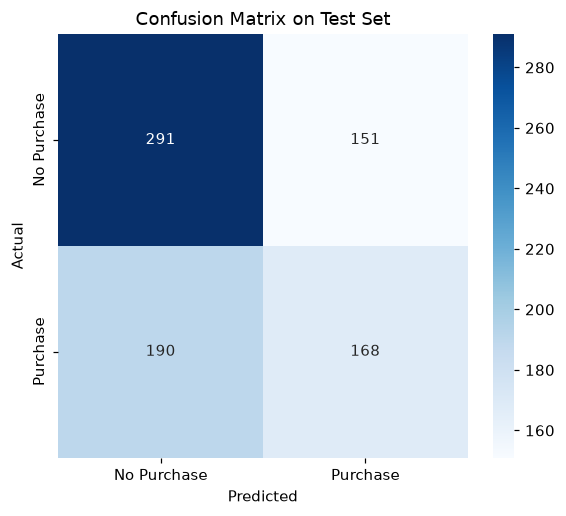

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính toán ma trận nhầm lẫn trên tập test
cm = confusion_matrix(y_test, y_pred)

# Tạo biểu đồ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [61]:
# =====================================================================
# BỔ SUNG CHỈ SỐ ĐẦY ĐỦ SO SÁNH (GRU vs Decision Tree vs LightGBM)
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score
)

THRESHOLD = 0.5  # giữ 0.5 để so sánh công bằng

y_proba_gru = gru_model.predict(
    [X_event_test, X_numeric_test, X_static_test], verbose=0
).ravel()
y_pred_gru = (y_proba_gru >= THRESHOLD).astype(int)

def full_metrics(y_true, y_pred, y_proba, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced acc": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen kappa": cohen_kappa_score(y_true, y_pred),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

comp_table = pd.DataFrame([
    full_metrics(y_test, y_pred_gru, y_proba_gru, "GRU (end-to-end)"),
    full_metrics(y_test, y_pred_dt, y_proba_dt, "Decision Tree (on GRU embedding)"),
    full_metrics(y_test, y_pred_lgb, y_proba_lgb, "LightGBM Classifier"),
]).set_index("Model").T

print("=== TABLE 9: SO SÁNH ĐẦY ĐỦ CÁC MÔ HÌNH (ngưỡng = 0.5) ===")
print(comp_table.round(4).to_string())


=== TABLE 9: SO SÁNH ĐẦY ĐỦ CÁC MÔ HÌNH (ngưỡng = 0.5) ===
Model         GRU (end-to-end)  Decision Tree (on GRU embedding)  LightGBM Classifier
Accuracy                0.5750                            0.5738               0.5600
AUC                     0.6219                            0.5653               0.5816
Precision               0.5208                            0.5266               0.5077
Recall                  0.6285                            0.4693               0.5531
Specificity             0.5317                            0.6584               0.5656
NPV                     0.6386                            0.6050               0.6098
F1                      0.5696                            0.4963               0.5294
Balanced acc            0.5801                            0.5638               0.5593
MCC                     0.1598                            0.1296               0.1181
Cohen kappa             0.1571                            0.1290               0.

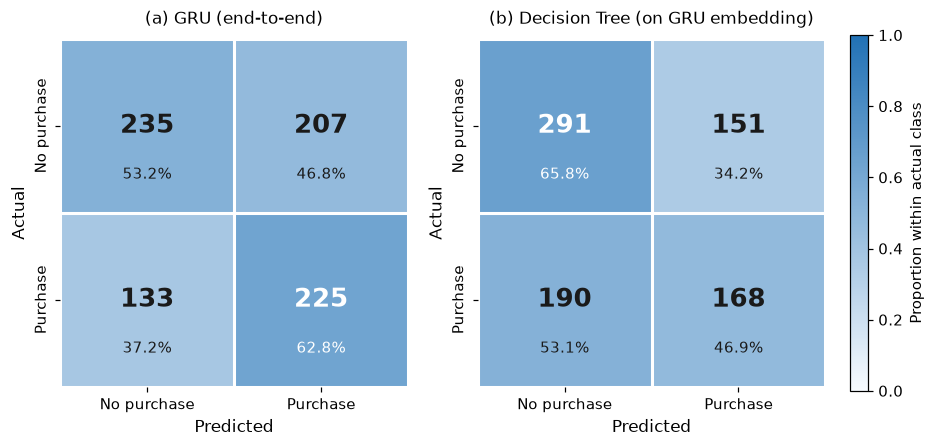

(a) GRU (end-to-end): TN=235  FP=207  FN=133  TP=225
(b) Decision Tree (on GRU embedding): TN=291  FP=151  FN=190  TP=168


In [62]:
# =====================================================================
# FIG 2 - CONFUSION MATRIX (GRU vs Decision Tree)
# Vị trí: đặt NGAY SAU cell tính chỉ số đầy đủ (cần y_pred_gru và y_pred)
# Thay thế hoàn toàn Cell 30 cũ - cell đó chỉ vẽ 1 ma trận và đã thừa
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

LABELS = ["No purchase", "Purchase"]

# Bảng màu xanh nhạt -> đậm, an toàn khi in trắng đen
cmap = LinearSegmentedColormap.from_list("blues", ["#f7fbff", "#2171b5"])

panels = [
    ("(a) GRU (end-to-end)", confusion_matrix(y_test, y_pred_gru)),
    ("(b) Decision Tree (on GRU embedding)", confusion_matrix(y_test, y_pred)),
]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))

for ax, (title, cm) in zip(axes, panels):
    # Chuẩn hoá theo hàng (theo lớp thực tế) để tô màu; số hiển thị vẫn là count
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # Chữ trắng trên nền đậm, chữ đen trên nền nhạt
            colour = "white" if cm_norm[i, j] > 0.55 else "#1a1a1a"
            ax.text(j, i, f"{cm[i, j]}",
                    ha="center", va="center",
                    fontsize=17, fontweight="bold", color=colour)
            ax.text(j, i + 0.28, f"{cm_norm[i, j]:.1%}",
                    ha="center", va="center",
                    fontsize=10, color=colour)

    ax.set_xticks([0, 1], LABELS, fontsize=10)
    ax.set_yticks([0, 1], LABELS, fontsize=10, rotation=90, va="center")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)

    # Viền ô cho dễ đọc khi in
    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.03,
             label="Proportion within actual class")

plt.savefig(os.path.join(FIG_DIR, "fig2_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- In lại số để đối chiếu với Table 10 ---
for title, cm in panels:
    tn, fp, fn, tp = cm.ravel()
    print(f"{title}: TN={tn}  FP={fp}  FN={fn}  TP={tp}")

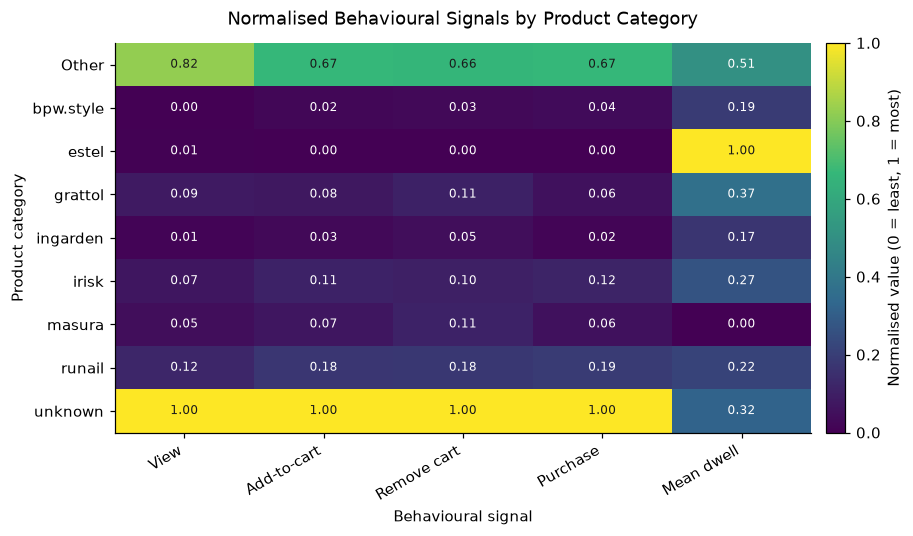

>> FIG 2 raw counts
            View  Add-to-cart  Remove cart  Purchase  Mean dwell
category                                                        
Other      34152        16652         8788      4095     66405.8
bpw.style   1551         1212          700       399     42437.1
estel       1845          722          302       183    103912.5
grattol     4945         2531         1686       516     55952.9
ingarden    2059         1394          888       278     41019.2
irisk       4454         3337         1638       862     48346.1
masura      3385         2471         1750       525     27972.7
runail      6392         4905         2610      1283     44477.1
unknown    41204        24573        13169      6046     52107.5


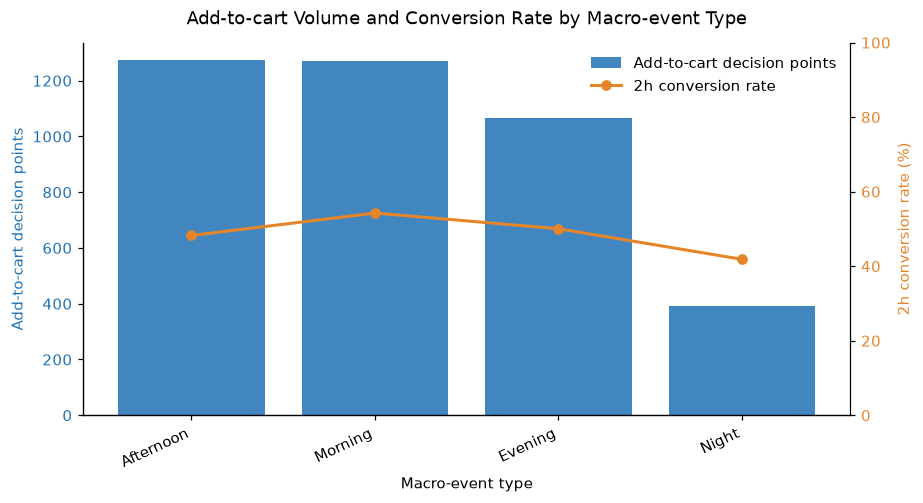

>> FIG 3
                  volume  conv_pct
event_type_macro                  
Afternoon           1273      48.2
Morning             1270      54.3
Evening             1065      50.0
Night                392      41.8
   Pearson r=0.873 p=0.127 | Spearman rho=0.400 p=0.600
   normal_day 50.0% vs event days 50.0%


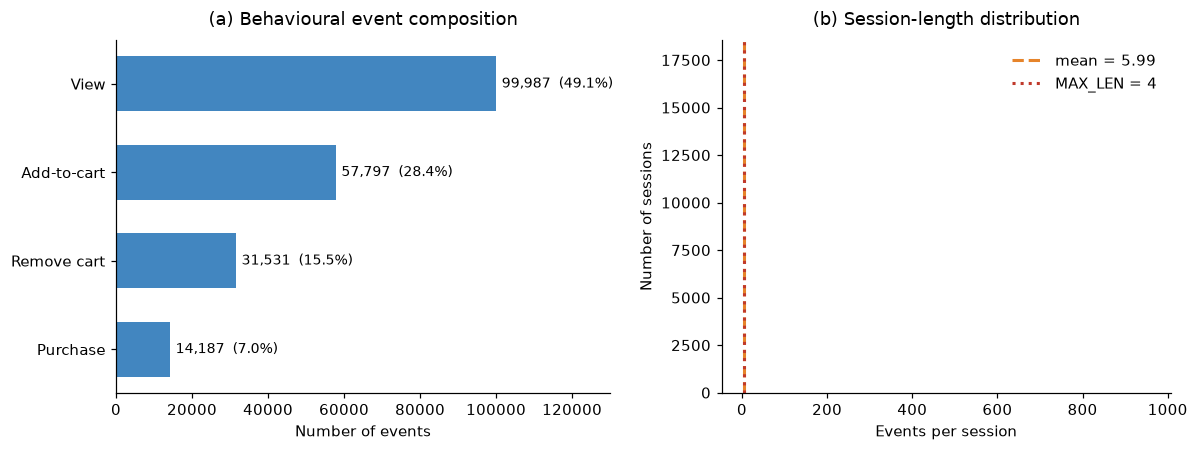

>> FIG 4
   sessions=33955 mean=5.99 median=1 max=959
   <=2 events: 64.4% | <=4 events: 76.1%


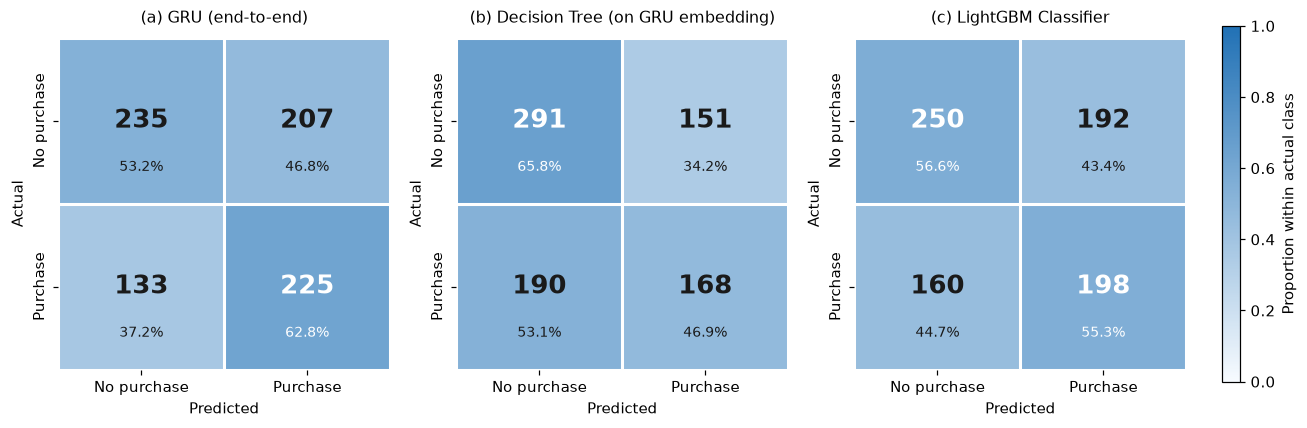

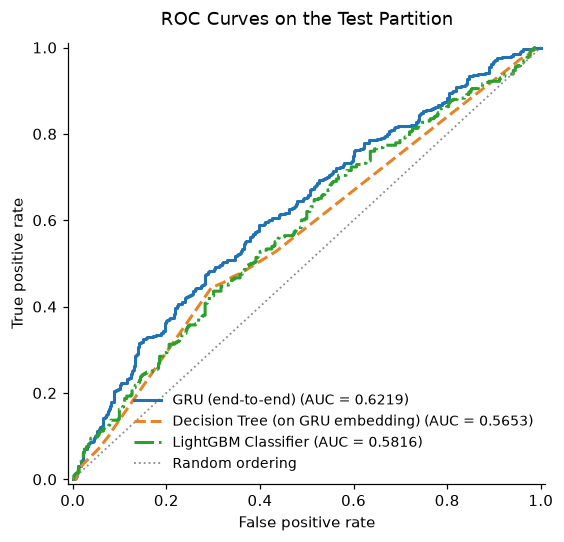

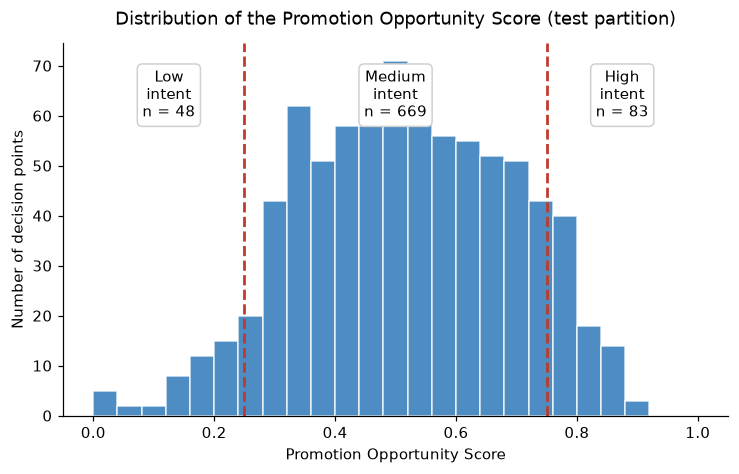

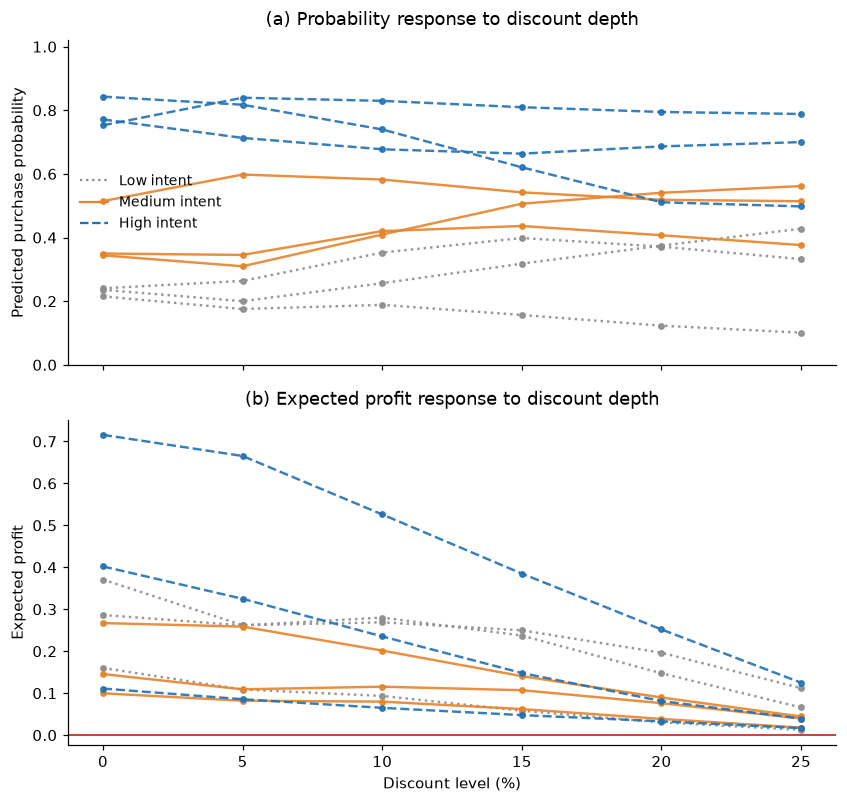

>> FIG 8 - elasticity direction per case
   case 1 [Low intent   ] margin 30.0%  p0=0.2404 p25=0.3323  RISE  rel=1.382x
   case 2 [Low intent   ] margin 30.0%  p0=0.2153 p25=0.1011  FALL  rel=0.470x
   case 3 [Low intent   ] margin 30.0%  p0=0.2358 p25=0.4278  RISE  rel=1.814x
   case 4 [Medium intent] margin 30.0%  p0=0.3498 p25=0.3763  RISE  rel=1.076x
   case 5 [Medium intent] margin 30.0%  p0=0.5146 p25=0.5142  FALL  rel=0.999x
   case 6 [Medium intent] margin 30.0%  p0=0.3442 p25=0.5618  RISE  rel=1.632x
   case 7 [High intent  ] margin 30.0%  p0=0.8429 p25=0.4979  FALL  rel=0.591x
   case 8 [High intent  ] margin 30.0%  p0=0.7526 p25=0.7884  RISE  rel=1.048x
   case 9 [High intent  ] margin 30.0%  p0=0.7712 p25=0.7001  FALL  rel=0.908x


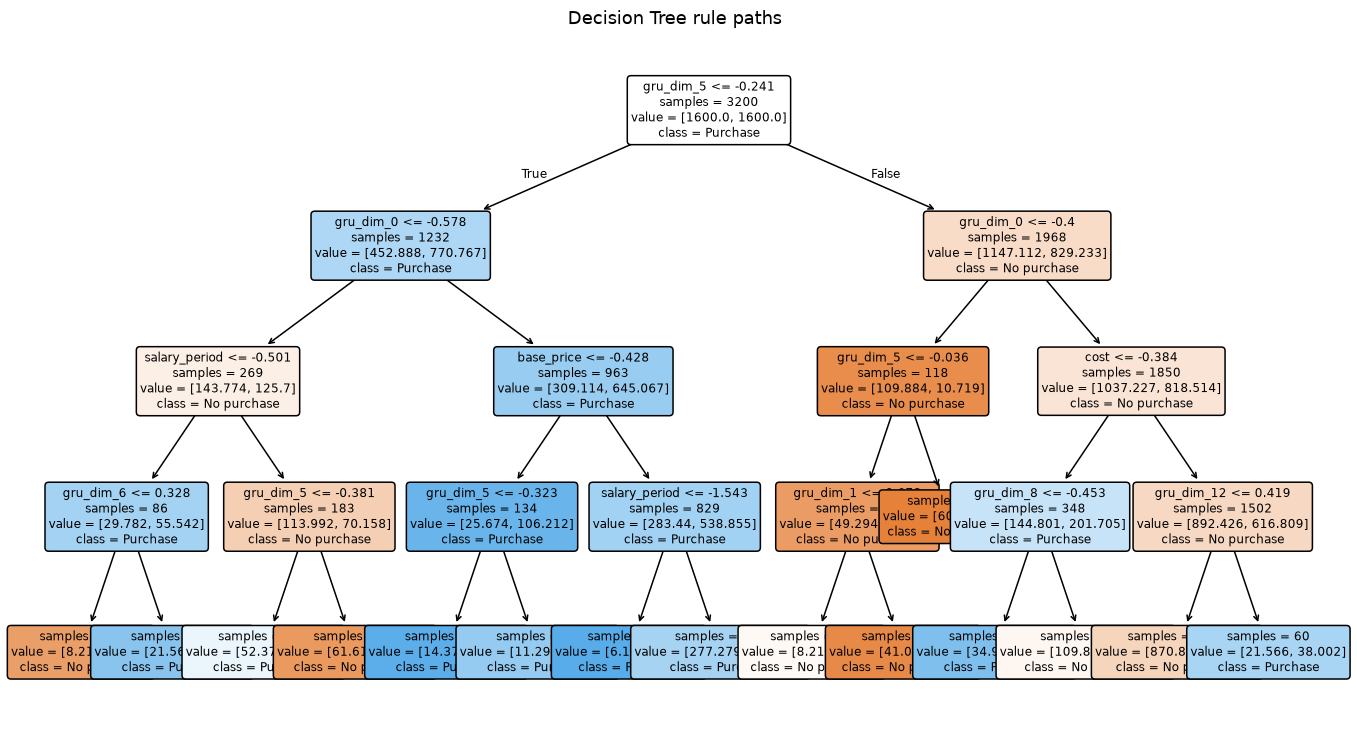

In [63]:
# =====================================================================
#  FIGURES 2-8  (khớp với Sections 4-5 bản FINAL)
#  Dán vào cuối notebook GRU__2_.ipynb, chạy tuần tự.
#  Mỗi khối lưu PNG 300 dpi -> tải về dán vào Word.
#
#  BIẾN CẦN CÓ SẴN (đã tạo ở các cell trước):
#    df, decision_points, labels, test_idx
#    y_test, y_pred, y_proba          (Decision Tree, Cell 25)
#    y_pred_gru, y_proba_gru          (Cell 31)
#    importances                      (Series, Cell 27)
#    all_sim_results                  (list DataFrame, Cell 29)
#    dt_model, all_feature_names      (Cell 25, 27)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

BLUE, ORANGE, GREY, RED = "#2171b5", "#e6842a", "#8c8c8c", "#c0392b"
EV_ORDER = ["detail_click", "add_to_cart", "remove_cart", "purchase"]
EV_LABEL = ["View", "Add-to-cart", "Remove cart", "Purchase"]


# =====================================================================
#  FIG 2 - Normalised heatmap: behavioural signals x category
# =====================================================================
mat = pd.crosstab(df["category"], df["event_type_behav"]).reindex(
    columns=EV_ORDER, fill_value=0)
mat.columns = EV_LABEL
mat["Mean dwell"] = df.groupby("category")["dwell_time"].mean()

norm = (mat - mat.min()) / (mat.max() - mat.min()).replace(0, 1)

cmap = LinearSegmentedColormap.from_list(
    "vir", ["#440154", "#31688e", "#35b779", "#fde725"])

fig, ax = plt.subplots(figsize=(8.6, 4.6))
im = ax.imshow(norm.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
for i in range(norm.shape[0]):
    for j in range(norm.shape[1]):
        v = norm.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v < 0.6 else "#1a1a1a")
ax.set_xticks(range(norm.shape[1]), norm.columns, rotation=30, ha="right")
ax.set_yticks(range(norm.shape[0]), norm.index)
ax.set_xlabel("Behavioural signal"); ax.set_ylabel("Product category")
ax.set_title("Normalised Behavioural Signals by Product Category", pad=12)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02,
             label="Normalised value (0 = least, 1 = most)")
plt.savefig(os.path.join(FIG_DIR, "fig2_heatmap.png"), dpi=300, bbox_inches="tight"); plt.show()

print(">> FIG 2 raw counts")
print(mat.round(1).to_string())


# =====================================================================
#  FIG 3 - Add-to-cart volume + conversion rate by macro-event type
# =====================================================================
dp = decision_points.copy()
dp["label"] = labels

grp = dp.groupby("event_type_macro").agg(
    volume=("label", "size"), conv=("label", "mean")
).sort_values("volume", ascending=False)

fig, ax1 = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(grp))
ax1.bar(x, grp["volume"], color=BLUE, alpha=0.85, label="Add-to-cart decision points")
ax1.set_xticks(x, grp.index, rotation=25, ha="right")
ax1.set_ylabel("Add-to-cart decision points", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xlabel("Macro-event type")

ax2 = ax1.twinx()
ax2.plot(x, grp["conv"] * 100, color=ORANGE, marker="o", linewidth=2,
         label="2h conversion rate")
ax2.set_ylabel("2h conversion rate (%)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax2.spines["right"].set_visible(True)
ax2.set_ylim(0, 100)

h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", frameon=False)
ax1.set_title("Add-to-cart Volume and Conversion Rate by Macro-event Type", pad=12)
plt.savefig(os.path.join(FIG_DIR, "fig3_dualaxis.png"), dpi=300, bbox_inches="tight"); plt.show()

from scipy import stats
r, p = stats.pearsonr(grp["volume"], grp["conv"])
rs, ps = stats.spearmanr(grp["volume"], grp["conv"])
print(">> FIG 3")
print(grp.assign(conv_pct=(100 * grp.conv).round(1))[["volume", "conv_pct"]].to_string())
print(f"   Pearson r={r:.3f} p={p:.3f} | Spearman rho={rs:.3f} p={ps:.3f}")
print(f"   normal_day {100*dp[dp.macro_level==0].label.mean():.1f}% vs "
      f"event days {100*dp[dp.macro_level>0].label.mean():.1f}%")


# =====================================================================
#  FIG 4 - Event composition + session-length distribution
# =====================================================================
counts = df["event_type_behav"].value_counts().reindex(EV_ORDER)
sess_len = df.groupby("session_id").size()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
ypos = np.arange(len(EV_ORDER))[::-1]
ax.barh(ypos, counts.values, color=BLUE, alpha=0.85, height=0.62)
for y, v in zip(ypos, counts.values):
    ax.text(v + counts.max() * 0.015, y, f"{v:,}  ({v/len(df):.1%})",
            va="center", fontsize=9)
ax.set_yticks(ypos, EV_LABEL)
ax.set_xlabel("Number of events")
ax.set_xlim(0, counts.max() * 1.3)
ax.set_title("(a) Behavioural event composition", pad=10)

ax = axes[1]
bins = np.arange(0.5, sess_len.max() + 1.5, 1)
ax.hist(sess_len, bins=bins, color=GREY, edgecolor="white")
ax.axvline(sess_len.mean(), color=ORANGE, linestyle="--", linewidth=2,
           label=f"mean = {sess_len.mean():.2f}")
ax.axvline(4, color=RED, linestyle=":", linewidth=2,
           label="MAX_LEN = 4")
ax.set_xlabel("Events per session"); ax.set_ylabel("Number of sessions")
ax.legend(frameon=False)
ax.set_title("(b) Session-length distribution", pad=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig4_composition_sessions.png"), dpi=300, bbox_inches="tight"); plt.show()

print(">> FIG 4")
print(f"   sessions={sess_len.count()} mean={sess_len.mean():.2f} "
      f"median={sess_len.median():.0f} max={sess_len.max()}")
print(f"   <=2 events: {(sess_len<=2).mean():.1%} | <=4 events: {(sess_len<=4).mean():.1%}")


# =====================================================================
#  FIG 5 - Confusion matrices (GRU vs Decision Tree)
# =====================================================================
from sklearn.metrics import confusion_matrix

LAB = ["No purchase", "Purchase"]
cmap_b = LinearSegmentedColormap.from_list("blues", ["#f7fbff", "#2171b5"])
panels = [
    ("(a) GRU (end-to-end)", confusion_matrix(y_test, y_pred_gru)),
    ("(b) Decision Tree (on GRU embedding)", confusion_matrix(y_test, y_pred_dt)),
    ("(c) LightGBM Classifier", confusion_matrix(y_test, y_pred_lgb))
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (title, cm) in zip(axes, panels):
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cmn, cmap=cmap_b, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            c = "white" if cmn[i, j] > 0.55 else "#1a1a1a"
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    fontsize=17, fontweight="bold", color=c)
            ax.text(j, i + 0.28, f"{cmn[i, j]:.1%}", ha="center", va="center",
                    fontsize=9, color=c)
    ax.set_xticks([0, 1], LAB); ax.set_yticks([0, 1], LAB, rotation=90, va="center")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=10.5, pad=10)
    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    for s in ax.spines.values(): s.set_visible(False)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.03,
             label="Proportion within actual class")
plt.savefig(os.path.join(FIG_DIR, "fig5_confusion.png"), dpi=300, bbox_inches="tight"); plt.show()


# =====================================================================
#  FIG 6 - ROC curves
# =====================================================================
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(5.6, 5.2))
for name, proba, colour, ls in [
    ("GRU (end-to-end)", y_proba_gru, BLUE, "-"),
    ("Decision Tree (on GRU embedding)", y_proba_dt, ORANGE, "--"),
    ("LightGBM Classifier", y_proba_lgb, "#2ca02c", "-."),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=colour, linestyle=ls, linewidth=2,
            label=f"{name} (AUC = {roc_auc_score(y_test, proba):.4f})")
ax.plot([0, 1], [0, 1], color=GREY, linestyle=":", linewidth=1.2,
        label="Random ordering")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC Curves on the Test Partition", pad=12)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
plt.savefig(os.path.join(FIG_DIR, "fig6_roc.png"), dpi=300, bbox_inches="tight"); plt.show()


# =====================================================================
#  FIG 7 - POS histogram with stratum boundaries
# =====================================================================
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.hist(y_proba_gru, bins=25, range=(0, 1), color=BLUE, alpha=0.8,
        edgecolor="white")
for b in (0.25, 0.75):
    ax.axvline(b, color=RED, linestyle="--", linewidth=1.8)

ymax = ax.get_ylim()[1]
for lo, hi, name in [(0.0, 0.25, "Low\nintent"),
                     (0.25, 0.75, "Medium\nintent"),
                     (0.75, 1.0, "High\nintent")]:
    k = int(((y_proba_gru >= lo) & (y_proba_gru < hi)).sum()) if hi < 1 \
        else int((y_proba_gru >= lo).sum())
    ax.text((lo + hi) / 2, ymax * 0.93, f"{name}\nn = {k}",
            ha="center", va="top", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor="#d0d0d0"))
ax.set_xlabel("Promotion Opportunity Score")
ax.set_ylabel("Number of decision points")
ax.set_title("Distribution of the Promotion Opportunity Score (test partition)",
             pad=12)
plt.savefig(os.path.join(FIG_DIR, "fig7_pos_hist.png"), dpi=300, bbox_inches="tight"); plt.show()


# =====================================================================
#  FIG 8 - Probability and expected profit vs discount (2 panels)
# =====================================================================
sim = pd.concat(all_sim_results, ignore_index=True)
# selected_cases ghép theo thứ tự low(3) -> medium(3) -> high(3)
STRATUM = {c: s for c, s in zip(range(1, 10),
           ["Low intent"] * 3 + ["Medium intent"] * 3 + ["High intent"] * 3)}
sim["stratum"] = sim["case"].map(STRATUM)

style = {"Low intent": ":", "Medium intent": "-", "High intent": "--"}
colour = {"Low intent": GREY, "Medium intent": ORANGE, "High intent": BLUE}

fig, axes = plt.subplots(2, 1, figsize=(7.8, 7.4), sharex=True)
for cid, g in sim.groupby("case"):
    st = g["stratum"].iloc[0]
    for ax, col in zip(axes, ["predicted_purchase_probability", "expected_profit"]):
        ax.plot(g["discount"] * 100, g[col], linestyle=style[st], color=colour[st],
                marker="o", markersize=3.5, linewidth=1.6, alpha=0.9)

axes[0].set_ylabel("Predicted purchase probability")
axes[0].set_title("(a) Probability response to discount depth", pad=10)
axes[0].set_ylim(0, 1.02)
axes[1].axhline(0, color=RED, linewidth=1.2)
axes[1].set_ylabel("Expected profit")
axes[1].set_xlabel("Discount level (%)")
axes[1].set_title("(b) Expected profit response to discount depth", pad=10)
axes[0].legend(handles=[Line2D([], [], color=colour[k], linestyle=style[k], label=k)
                        for k in style], loc="center left", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig8_discount_response.png"), dpi=300, bbox_inches="tight"); plt.show()

print(">> FIG 8 - elasticity direction per case")
for cid, g in sim.groupby("case"):
    p = g.sort_values("discount")["predicted_purchase_probability"].to_numpy()
    b = g["sale_price"].max(); up = g.loc[g.discount == 0, "unit_profit"].iloc[0]
    print(f"   case {cid} [{STRATUM[cid]:13s}] margin {up/b:5.1%}  "
          f"p0={p[0]:.4f} p25={p[-1]:.4f}  {'RISE' if p[-1]>p[0] else 'FALL'}  "
          f"rel={p[-1]/p[0]:.3f}x")


# =====================================================================
#  FIG A1 (phụ lục) - Decision Tree rule paths
# =====================================================================
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(dt_model, feature_names=all_feature_names,
          class_names=["No purchase", "Purchase"],
          filled=True, rounded=True, fontsize=8, ax=ax, impurity=False)
ax.set_title("Decision Tree rule paths", pad=12)
plt.savefig(os.path.join(FIG_DIR, "figA1_tree.png"), dpi=300, bbox_inches="tight"); plt.show()
